In [1]:
import numpy as np

def my_conv2d(image, kernel):
    im_h, im_w = image.shape
    k_h, k_w = kernel.shape
    pad_h = k_h // 2
    pad_w = k_w // 2
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='edge')
    out_h = im_h
    out_w = im_w
    output = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            output[i, j] = np.sum(padded[i:i+k_h, j:j+k_w] * kernel)
    return output

def mean_filter(image, kernel_size):
    kernel = np.ones((kernel_size, kernel_size)) / (kernel_size * kernel_size)
    return my_conv2d(image, kernel)

def gaussian_filter(image, kernel_size, sigma):
    ax = np.arange(-kernel_size // 2 + 1., kernel_size // 2 + 1.)
    xx, yy = np.meshgrid(ax, ax, indexing='ij')
    kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    kernel /= np.sum(kernel)
    return my_conv2d(image, kernel)

def median_filter(image, kernel_size):
    i_h, i_w = image.shape
    pad_h = kernel_size // 2
    pad_w = kernel_size // 2
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='edge')
    output = np.zeros_like(image)
    for i in range(i_h):
        for j in range(i_w):
            output[i, j] = np.median(padded[i:i+kernel_size, j:j+kernel_size])
    return output



In [ ]:
def gaussian_noise(image, mean=0, sigma=1):
    noise = np.random.normal(mean, sigma, image.shape)
    noisy = image + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

def salt_and_pepper_noise(image, salt_prob=0.05, pepper_prob=0.05):
    noisy = np.copy(image)
    total_pixels = image.size
    num_salt = int(total_pixels * salt_prob)
    num_pepper = int(total_pixels * pepper_prob)
    salt_coords = tuple(np.random.randint(0, dim, num_salt) for dim in image.shape)
    noisy[salt_coords] = 255
    pepper_coords = tuple(np.random.randint(0, dim, num_pepper) for dim in image.shape)
    noisy[pepper_coords] = 0
    return noisy

def psnr(original, denoised):
    mse = np.mean((original - denoised) ** 2)
    if mse == 0:
        return float('inf')
    max_pixel = 255.0
    return 20 * np.log10(max_pixel / np.sqrt(mse))

import cv2
def make_demo_image():
    img = np.zeros((200,200), np.uint8)
    cv2.rectangle(img,(30,30),(95,95),200,-1)
    cv2.circle(img,(140,60),30,150,-1)
    cv2.rectangle(img,(50,125),(160,170),100,-1)
    return img



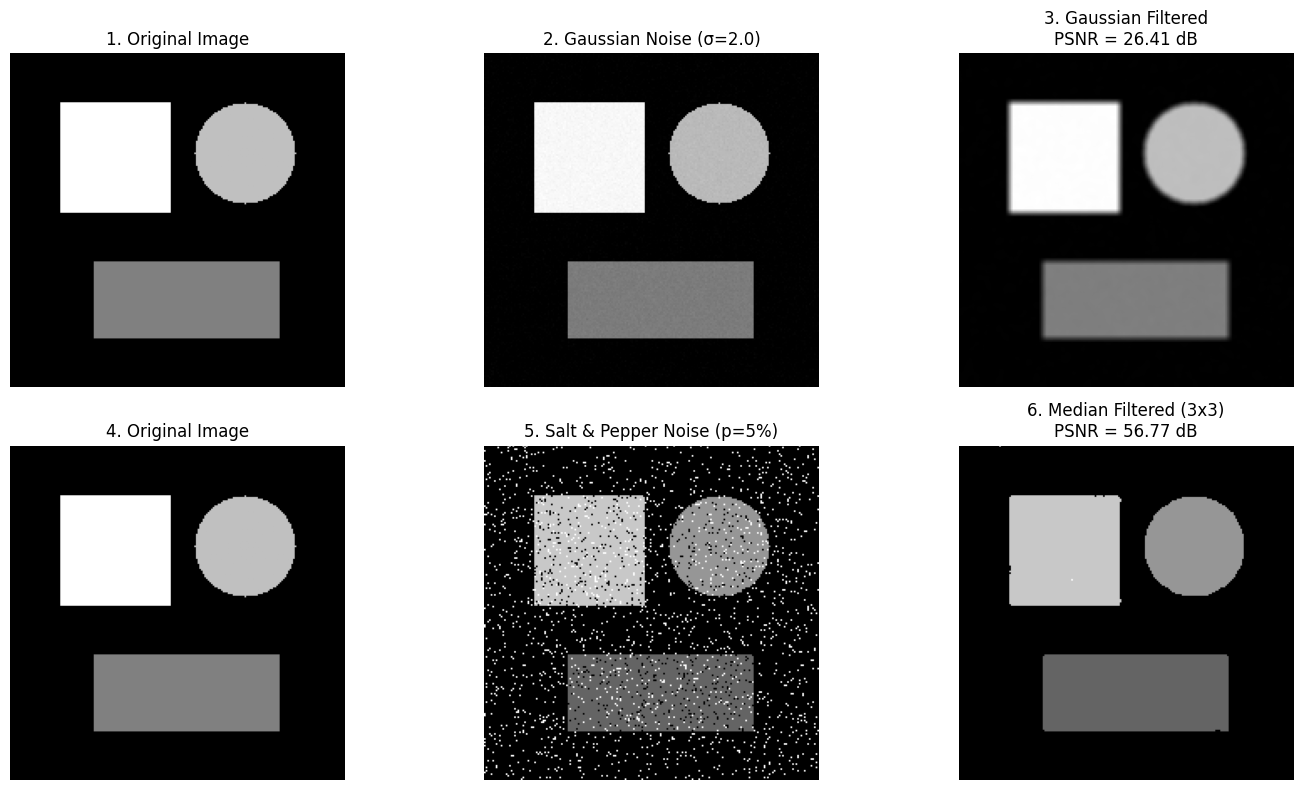

In [6]:
import matplotlib.pyplot as plt

# 确保之前定义的函数都在环境中：make_demo_image, gaussian_noise, salt_and_pepper_noise, 
# gaussian_filter, median_filter, psnr

# 1. 生成干净的原图
clean_img = make_demo_image()

# 2. 生成两种噪声图（固定参数，方便对比）
gaussian_noisy = gaussian_noise(clean_img, sigma=2.0)          # 高斯噪声
sp_noisy = salt_and_pepper_noise(clean_img, 0.05, 0.05)       # 椒盐噪声

# 3. 降噪处理
gaussian_denoised = gaussian_filter(gaussian_noisy, kernel_size=5, sigma=2.0)
median_denoised = median_filter(sp_noisy, kernel_size=3)

# 4. 计算 PSNR 数值（用于显示在标题上）
psnr_gaussian = psnr(clean_img, gaussian_denoised)
psnr_median = psnr(clean_img, median_denoised)

# 5. 开始绘图：2行3列
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# 第一行：高斯噪声处理流程
axes[0, 0].imshow(clean_img, cmap='gray')
axes[0, 0].set_title('1. Original Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(gaussian_noisy, cmap='gray')
axes[0, 1].set_title(f'2. Gaussian Noise (σ=2.0)')
axes[0, 1].axis('off')

axes[0, 2].imshow(gaussian_denoised, cmap='gray')
axes[0, 2].set_title(f'3. Gaussian Filtered\nPSNR = {psnr_gaussian:.2f} dB')
axes[0, 2].axis('off')

# 第二行：椒盐噪声处理流程
axes[1, 0].imshow(clean_img, cmap='gray')
axes[1, 0].set_title('4. Original Image')
axes[1, 0].axis('off')

axes[1, 1].imshow(sp_noisy, cmap='gray')
axes[1, 1].set_title('5. Salt & Pepper Noise (p=5%)')
axes[1, 1].axis('off')

axes[1, 2].imshow(median_denoised, cmap='gray')
axes[1, 2].set_title(f'6. Median Filtered (3x3)\nPSNR = {psnr_median:.2f} dB')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

最大绝对误差: 0.000015258789
平均绝对误差: 0.000002492332
是否完全一致（误差 < 1e-6）: True


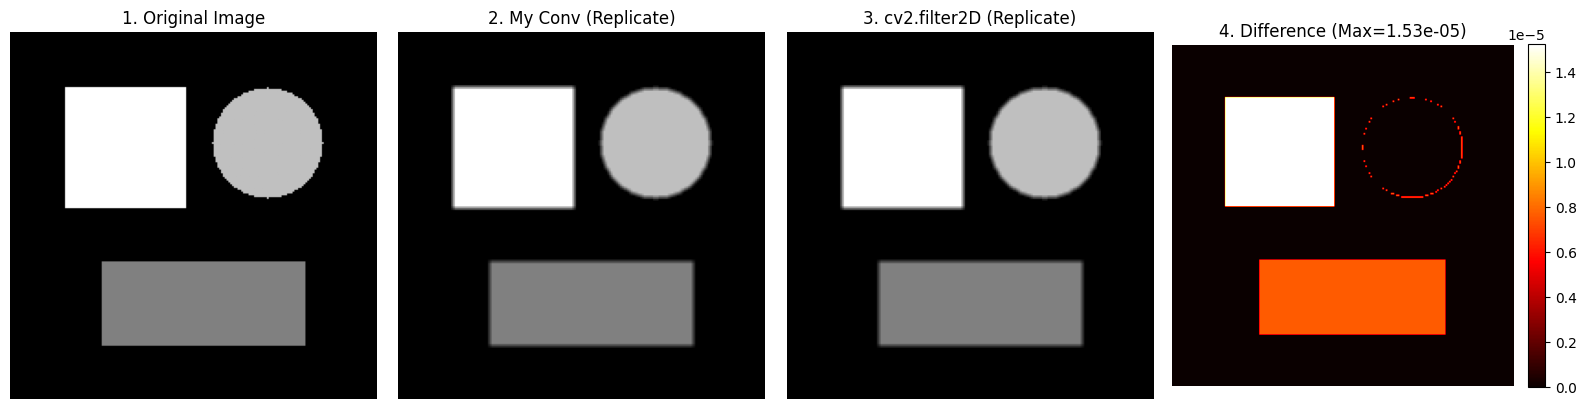

In [8]:
image = make_demo_image()

# ---------- 定义均值核（3x3） ----------
kernel = np.ones((3, 3), dtype=np.float32) / 9.0

# ---------- 1. 使用你自己的卷积函数 ----------
result_my = my_conv2d(image, kernel)  # 返回 float64

# ---------- 2. 使用 OpenCV 的 filter2D (强制浮点输出，不做取整) ----------
# 将图像转为 float32，这样 OpenCV 就不会做 uint8 舍入了
image_float = image.astype(np.float32)
result_cv = cv2.filter2D(image_float, -1, kernel, borderType=cv2.BORDER_REPLICATE)

# 此时 result_cv 是 float32，你的 my_conv2d 返回 float64，都带小数
# 计算差值（统一转成 float64）
diff = np.abs(result_my - result_cv.astype(np.float64))
max_diff = np.max(diff)
mean_diff = np.mean(diff)

print(f"最大绝对误差: {max_diff:.12f}")
print(f"平均绝对误差: {mean_diff:.12f}")
print(f"是否完全一致（误差 < 1e-6）: {np.allclose(result_my, result_cv, atol=1e-6)}")

# ---------- 4. 可视化对比 ----------
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(image, cmap='gray')
axes[0].set_title('1. Original Image')
axes[0].axis('off')

axes[1].imshow(result_my, cmap='gray')
axes[1].set_title('2. My Conv (Replicate)')
axes[1].axis('off')

axes[2].imshow(result_cv, cmap='gray')
axes[2].set_title('3. cv2.filter2D (Replicate)')
axes[2].axis('off')

# 差异图用 hot 色阶放大显示，方便观察
im = axes[3].imshow(diff, cmap='hot')
axes[3].set_title(f'4. Difference (Max={max_diff:.2e})')
axes[3].axis('off')
fig.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()